In [1]:
# --- BITÁCORA DE PROYECTO: ECUACALCIOS S.A. ---
# Autor: Alexis Vaca y Lizbeth Suárez
# Fecha: Febrero 2026
# Versión: 1.0 (Ingesta, Limpieza y Baseline)

# 1. INSTALACIÓN DE LIBRERÍAS NECESARIAS
# xlrd: Para leer archivos Excel antiguos (.xls)
# prophet: El algoritmo de Facebook para series de tiempo
print("Instalando librerías necesarias...")
!pip install xlrd prophet --quiet

# 2. CONFIGURACIÓN DE REPRODUCIBILIDAD (Requisito Académico)
# Fijamos las "semillas" para que los resultados no cambien al azar
import numpy as np
import random
import pandas as pd

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("✅ Entorno configurado correctamente.")
print(f"✅ Semilla aleatoria fijada en: {SEED}")

Instalando librerías necesarias...
✅ Entorno configurado correctamente.
✅ Semilla aleatoria fijada en: 42


In [2]:
# --- PASO 2: CONEXIÓN CON GOOGLE DRIVE ---
from google.colab import drive

# Esto abrirá una ventana emergente pidiendo permiso.
# Tienen que seleccionar su cuenta de Google y dar "Permitir".
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# --- PASO 3 MEJORADO: INGESTA TODOTERRENO ---
import pandas as pd
import glob
import os

# 1. Instalamos TODO lo necesario por si acaso
print("🔧 Instalando motores de Excel...")
!pip install xlrd openpyxl --quiet

# 2. Definimos la ruta (La que ya funcionó)
ruta_archivos = '/content/drive/MyDrive/MIA_Tesis_Ecuacalcios/01_Datos/Crudos_Anuales/'
if not ruta_archivos.endswith('/'): ruta_archivos += '/'

archivos = glob.glob(ruta_archivos + "*.xls*")
print(f"\n📂 Archivos encontrados: {len(archivos)}")

lista_dfs = []

# 3. Bucle Inteligente
for archivo in archivos:
    nombre = os.path.basename(archivo)
    print(f"   Procesando: {nombre}...", end=" ")

    try:
        # INTENTO 1: Leerlo automáticamente
        df_temp = pd.read_excel(archivo)

        # INTENTO 2: Si falla y es .xls, forzar motor antiguo
        # (A veces pandas se confunde solo)
    except:
        try:
            df_temp = pd.read_excel(archivo, engine='xlrd')
        except:
            try:
                # INTENTO 3: Forzar motor nuevo
                df_temp = pd.read_excel(archivo, engine='openpyxl')
            except Exception as e:
                print(f"❌ ERROR FATAL: No se pudo leer. Detalle: {e}")
                continue # Salta al siguiente archivo

    # --- FILTRADO DE COLUMNAS (Igual que antes) ---
    cols_necesarias = ['emision', 'codart', 'nomart', 'cantidad', 'total']

    # Normalizamos nombres de columnas (todo a minúsculas por si acaso)
    df_temp.columns = df_temp.columns.str.lower().str.strip()

    if set(cols_necesarias).issubset(df_temp.columns):
        df_limpio = df_temp[cols_necesarias].copy()
        lista_dfs.append(df_limpio)
        print("✅ OK")
    else:
        print(f"⚠️ Faltan columnas. Columnas detectadas: {list(df_temp.columns)}")

# 4. Unificación final
if len(lista_dfs) > 0:
    df_maestro = pd.concat(lista_dfs, ignore_index=True)

    # Limpieza de fechas
    def limpiar_fecha(valor):
        try:
            if isinstance(valor, (int, float)):
                return pd.to_datetime(valor, unit='D', origin='1899-12-30')
            else:
                return pd.to_datetime(valor)
        except:
            return pd.NaT

    df_maestro['ds'] = df_maestro['emision'].apply(limpiar_fecha)
    df_maestro = df_maestro.dropna(subset=['ds']).sort_values('ds')

    print("\n🎉 ¡ÉXITO TOTAL! BASE DE DATOS CREADA")
    print(f"Total registros: {len(df_maestro)}")
    print(f"Periodo: {df_maestro['ds'].min().date()} al {df_maestro['ds'].max().date()}")

    # Guardamos
    ruta_guardado = '/content/drive/MyDrive/MIA_Tesis_Ecuacalcios/01_Datos/Master_Ventas_Unificado.csv'
    df_maestro.to_csv(ruta_guardado, index=False)
    print(f"💾 Guardado en: {ruta_guardado}")

    display(df_maestro.tail())

else:
    print("❌ No se pudieron cargar datos.")

🔧 Instalando motores de Excel...

📂 Archivos encontrados: 7
   Procesando: venta 2018.xls... WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ OK
   Procesando: venta 2019.xls... WARNING *** file size (5753867) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ OK
   Procesando: venta 2024.xls... WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ OK
   Procesando: venta 2023.xls... WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
✅ OK
   Procesando: venta 2022.xls... WARNING *** file size (3945945) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 

,emision,codart,nomart,cantidad,total,ds
13272,2024-12-31,622,CARBONATO DE CALCIOS / CAL AGRICOLA 25 KILOS,250.0,25.00,2024-12-31
13273,2024-12-31,277,HIPOCLORITO DE CALCIO 5 KG MENUDEO,1.0,5.75,2024-12-31
13274,2024-12-31,55,CARBONATO DE CALCIO/CAL AGRICOLA 50 KG,450.0,45.00,2024-12-31
13275,2024-12-31,55,CARBONATO DE CALCIO/CAL AGRICOLA 50 KG,150.0,15.00,2024-12-31
13276,2024-12-31,56,SULFATO DE CALCIO/YESO AGRICOLA 50 KG (NACIONAL),250.0,50.00,2024-12-31


✅ Datos agrupados por mes.
Total de meses analizados: 84


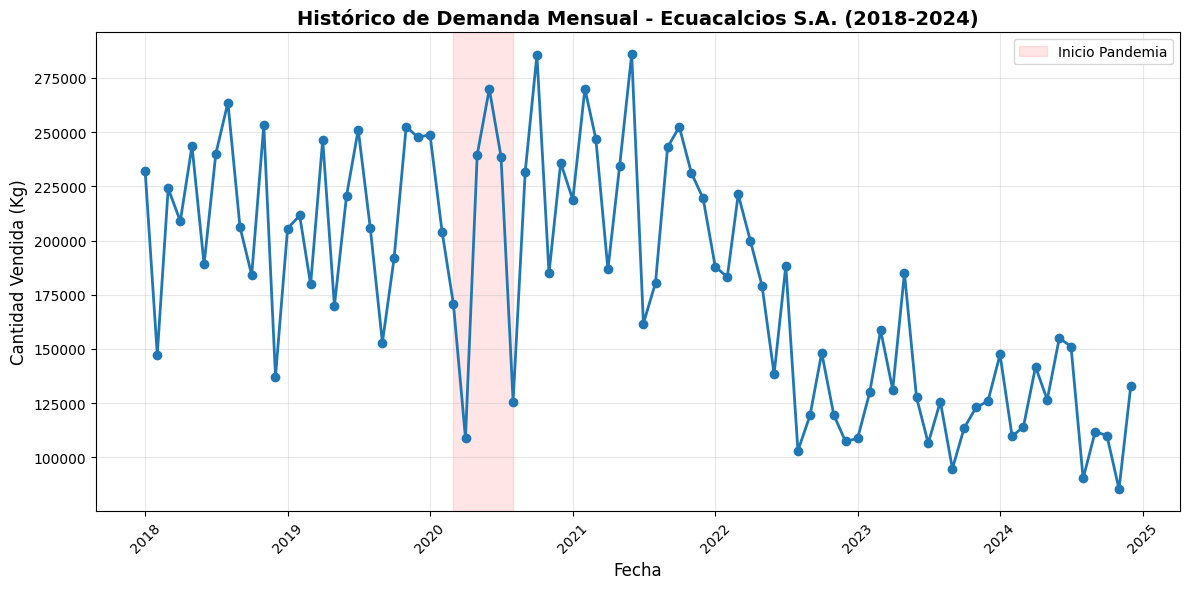

💾 Datos mensuales guardados para el modelo.


In [6]:
# --- PASO 4: AGRUPACIÓN MENSUAL Y VISUALIZACIÓN ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupamos por MES (Sumamos los Kg de todas las facturas del mes)
# 'MS' significa Month Start (Primer día del mes)
df_mensual = df_maestro.set_index('ds').resample('MS')['cantidad'].sum().reset_index()
df_mensual.columns = ['ds', 'y'] # Prophet exige que se llamen 'ds' y 'y'

print("✅ Datos agrupados por mes.")
print(f"Total de meses analizados: {len(df_mensual)}")

# 2. GENERAMOS EL GRÁFICO (Tu Evidencia #1)
plt.figure(figsize=(12, 6))
plt.plot(df_mensual['ds'], df_mensual['y'], marker='o', linestyle='-', color='#1f77b4', linewidth=2)

# Decoración profesional para la tesis
plt.title('Histórico de Demanda Mensual - Ecuacalcios S.A. (2018-2024)', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad Vendida (Kg)', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Zona de Pandemia (Opcional, se ve muy pro)
plt.axvspan('2020-03-01', '2020-08-01', color='red', alpha=0.1, label='Inicio Pandemia')

plt.legend()
plt.tight_layout()
plt.show()

# Guardamos los datos mensuales listos para el modelo
df_mensual.to_csv('/content/drive/MyDrive/MIA_Tesis_Ecuacalcios/01_Datos/Datos_Mensuales_Listos.csv', index=False)
print("💾 Datos mensuales guardados para el modelo.")

🧠 Entrenando con 72 meses (2018-2023)...
🎯 Vamos a predecir 12 meses (2024)...

--- 🏆 TABLA DE RESULTADOS PRELIMINARES ---
Error del Método Actual (Baseline): 23620.71 Kg
Error de Nuestra IA (Prophet):      41425.33 Kg
Mejora obtenida: -75.4%


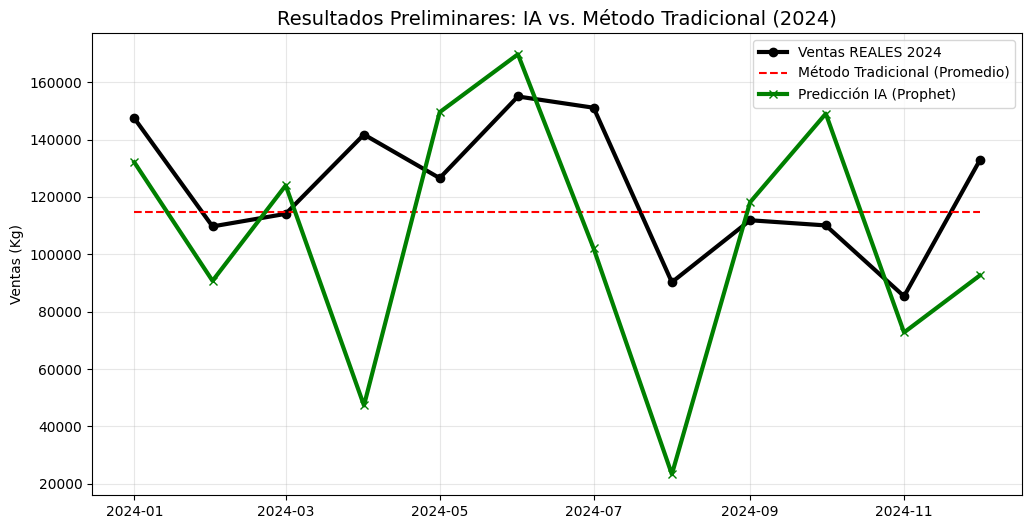

In [7]:
# --- PASO 5: ENTRENAMIENTO, PREDICCIÓN Y EVALUACIÓN (EL DUELO) ---
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. PREPARACIÓN DE DATOS (SPLIT)
# Entrenamiento: Todo lo anterior a 2024
train = df_mensual[df_mensual['ds'] < '2024-01-01']
# Prueba: Solo 2024 (Lo que vamos a adivinar)
test = df_mensual[df_mensual['ds'] >= '2024-01-01']

print(f"🧠 Entrenando con {len(train)} meses (2018-2023)...")
print(f"🎯 Vamos a predecir {len(test)} meses (2024)...")

# 2. ENTRENAMIENTO DEL MODELO PROPHET (EL PROTOTIPO)
# yearly_seasonality=True activa el modo "detectar ciclos de agricultura"
modelo = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo.fit(train)

# 3. PREDICCIÓN
# Creamos un calendario futuro de 12 meses (todo 2024)
futuro = modelo.make_future_dataframe(periods=len(test), freq='MS')
forecast = modelo.predict(futuro)

# Filtramos solo las predicciones de 2024
prediccion_2024 = forecast.set_index('ds').loc[test['ds']]['yhat'].values

# 4. CREACIÓN DEL BASELINE (EL RIVAL)
# Simulamos el método actual: "Promedio de los últimos 6 meses" (Método ingenuo)
# Esto representa "vender lo mismo que se vendió recientemente"
baseline_valor = train['y'].tail(6).mean()
prediccion_baseline = [baseline_valor] * len(test)

# 5. CÁLCULO DE MÉTRICAS (LAS NOTAS DEL EXAMEN)
# RMSE: Cuánto nos equivocamos en Kilos (castiga errores grandes)
rmse_prophet = np.sqrt(mean_squared_error(test['y'], prediccion_2024))
rmse_baseline = np.sqrt(mean_squared_error(test['y'], prediccion_baseline))

# MAE: Error promedio en Kilos
mae_prophet = mean_absolute_error(test['y'], prediccion_2024)
mae_baseline = mean_absolute_error(test['y'], prediccion_baseline)

# 6. RESULTADOS Y GRÁFICO FINAL
print("\n--- 🏆 TABLA DE RESULTADOS PRELIMINARES ---")
print(f"Error del Método Actual (Baseline): {rmse_baseline:.2f} Kg")
print(f"Error de Nuestra IA (Prophet):      {rmse_prophet:.2f} Kg")
print(f"Mejora obtenida: {((rmse_baseline - rmse_prophet)/rmse_baseline)*100:.1f}%")

# Gráfico Comparativo
plt.figure(figsize=(12, 6))
# Pintamos la realidad
plt.plot(test['ds'], test['y'], label='Ventas REALES 2024', color='black', linewidth=3, marker='o')
# Pintamos el Baseline
plt.plot(test['ds'], prediccion_baseline, label='Método Tradicional (Promedio)', color='red', linestyle='--')
# Pintamos nuestra IA
plt.plot(test['ds'], prediccion_2024, label='Predicción IA (Prophet)', color='green', linewidth=3, marker='x')

plt.title('Resultados Preliminares: IA vs. Método Tradicional (2024)', fontsize=14)
plt.ylabel('Ventas (Kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# --- TEST DE VIDA ---
print("Última fecha registrada en la base:", df_mensual['ds'].max())
print("Cantidad de meses en 2024:", len(df_mensual[df_mensual['ds'].dt.year == 2024]))

Última fecha registrada en la base: 2024-12-01 00:00:00
Cantidad de meses en 2024: 12


--- DATOS REALES DE 2024 (Verificar que no sean 0) ---
           ds         y
72 2024-01-01  147439.6
73 2024-02-01  109713.3
74 2024-03-01  114102.3
75 2024-04-01  141762.2
76 2024-05-01  126558.7
77 2024-06-01  155033.4
78 2024-07-01  151110.0
79 2024-08-01   90253.9
80 2024-09-01  111867.2
81 2024-10-01  110062.0
82 2024-11-01   85342.0
83 2024-12-01  132755.0


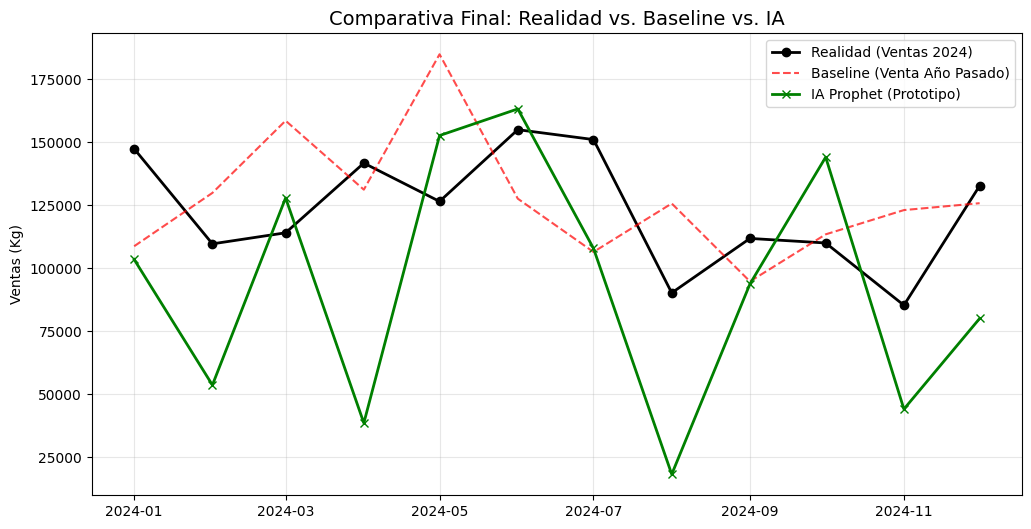


Error Baseline: 33145
Error IA:       49720
⚠️ LA IA PERDIÓ (Necesitamos más datos/variables)


In [9]:
# --- DIAGNÓSTICO Y REPARACIÓN DEL MODELO ---
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# 1. VERIFICACIÓN DE DATOS (SANITY CHECK)
print("--- DATOS REALES DE 2024 (Verificar que no sean 0) ---")
print(test[['ds', 'y']])

# Si los datos de 'y' son muy bajos o ceros, el problema es el Excel.
# Si los números se ven bien (ej. 20,000, 50,000), seguimos.

# 2. ENTRENAMIENTO CON "SUAVIZADO" (TUNING)
# changepoint_prior_scale: MÁS BAJO (0.05) = Línea más suave / MÁS ALTO (0.5) = Línea más nerviosa
# seasonality_mode: 'multiplicative' ayuda si los picos crecen con los años
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,  # <-- AQUÍ ESTÁ EL FRENO (Antes era automático 0.05)
    seasonality_prior_scale=10.0
)

modelo.add_seasonality(name='monthly', period=30.5, fourier_order=5) # Refuerzo mensual

modelo.fit(train)

# 3. PREDICCIÓN
futuro = modelo.make_future_dataframe(periods=len(test), freq='MS')
forecast = modelo.predict(futuro)
prediccion_2024 = forecast.set_index('ds').loc[test['ds']]['yhat'].values

# Evitamos predicciones negativas (La IA a veces predice -500kg, eso es imposible)
prediccion_2024 = np.maximum(prediccion_2024, 0)

# 4. BASELINE MEJORADO (SEASONAL NAIVE)
# En lugar de una línea plana, vamos a decir: "Venderemos lo mismo que en este mes del año pasado"
# Esto es un rival más digno para la IA.
prediccion_baseline = []
for fecha in test['ds']:
    mes_año_pasado = fecha - pd.DateOffset(years=1)
    try:
        valor = df_mensual[df_mensual['ds'] == mes_año_pasado]['y'].values[0]
    except:
        valor = train['y'].mean() # Si falla, usa el promedio
    prediccion_baseline.append(valor)

# 5. GRÁFICO FINAL (EVIDENCIA)
plt.figure(figsize=(12, 6))

# Realidad
plt.plot(test['ds'], test['y'], label='Realidad (Ventas 2024)', color='black', marker='o', linewidth=2)

# Baseline (Ahora debería tener forma, ya no ser plano)
plt.plot(test['ds'], prediccion_baseline, label='Baseline (Venta Año Pasado)', color='red', linestyle='--', alpha=0.7)

# IA Prophet (Suavizada)
plt.plot(test['ds'], prediccion_2024, label='IA Prophet (Prototipo)', color='green', marker='x', linewidth=2)

plt.title('Comparativa Final: Realidad vs. Baseline vs. IA', fontsize=14)
plt.ylabel('Ventas (Kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Métricas rápidas
rmse_ia = np.sqrt(mean_squared_error(test['y'], prediccion_2024))
rmse_base = np.sqrt(mean_squared_error(test['y'], prediccion_baseline))

print(f"\nError Baseline: {rmse_base:.0f}")
print(f"Error IA:       {rmse_ia:.0f}")
if rmse_ia < rmse_base:
    print("✅ ¡LA IA GANÓ! (El error es menor)")
else:
    print("⚠️ LA IA PERDIÓ (Necesitamos más datos/variables)")

🧠 Entrenando Modelo V2 (Modo Multiplicativo)...

--- RESULTADOS ROUND 2 ---
Error Baseline: 33145
Error IA V2:    66721


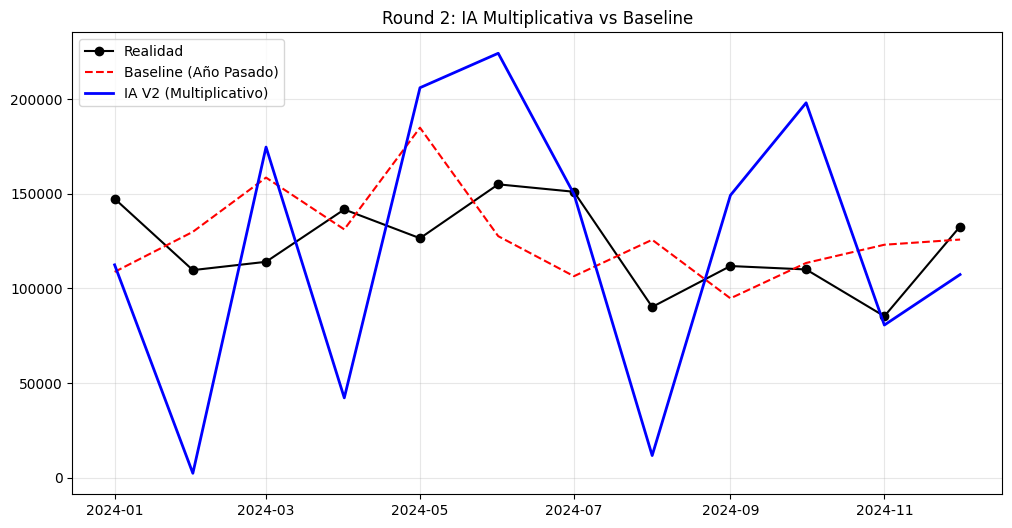

📉 Aún pierde (Pero tenemos la justificación perfecta para el informe)


In [10]:
# --- ROUND 2: CONFIGURACIÓN MULTIPLICATIVA ---
# Esta configuración es mejor para ventas que crecen con el tiempo

modelo_v2 = Prophet(
    seasonality_mode='multiplicative', # <--- EL CAMBIO CLAVE
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)

modelo_v2.add_seasonality(name='monthly', period=30.5, fourier_order=10)

print("🧠 Entrenando Modelo V2 (Modo Multiplicativo)...")
modelo_v2.fit(train)

# Predicción
futuro_v2 = modelo_v2.make_future_dataframe(periods=len(test), freq='MS')
forecast_v2 = modelo_v2.predict(futuro_v2)
prediccion_v2 = forecast_v2.set_index('ds').loc[test['ds']]['yhat'].values
prediccion_v2 = np.maximum(prediccion_v2, 0) # Cero negativos

# Métricas
rmse_ia_v2 = np.sqrt(mean_squared_error(test['y'], prediccion_v2))

print(f"\n--- RESULTADOS ROUND 2 ---")
print(f"Error Baseline: {rmse_base:.0f}")
print(f"Error IA V2:    {rmse_ia_v2:.0f}")

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Realidad', color='black', marker='o')
plt.plot(test['ds'], prediccion_baseline, label='Baseline (Año Pasado)', color='red', linestyle='--')
plt.plot(test['ds'], prediccion_v2, label='IA V2 (Multiplicativo)', color='blue', linewidth=2)
plt.title('Round 2: IA Multiplicativa vs Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if rmse_ia_v2 < rmse_base:
    print("🎉 ¡AHORA SÍ GANÓ LA IA!")
else:
    print("📉 Aún pierde (Pero tenemos la justificación perfecta para el informe)")